In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import sqlite3
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save our exported PNG charts
output_dir = "../reports/charts"
os.makedirs(output_dir, exist_ok=True)

# Connect to the SQLite database we built on Day 2
db_path = "../data/db/bluestock_mf.db"
conn = sqlite3.connect(db_path)

print(f"Connected to database. Charts will be saved to: {output_dir}")

Connected to database. Charts will be saved to: ../reports/charts


In [2]:
# Cell 2: NAV Trend Analysis 2022-2026
# Pull the NAV data joined with the scheme names
query_nav = """
    SELECT n.date, n.nav, f.scheme_name 
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    WHERE n.date >= '2022-01-01'
"""
df_nav = pd.read_sql_query(query_nav, conn)

# Ensure date is a datetime object
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Create the interactive Plotly line chart
fig = px.line(
    df_nav, 
    x='date', 
    y='nav', 
    color='scheme_name',
    title='Daily NAV Trend for Mutual Fund Schemes (2022–2026)',
    labels={'date': 'Date', 'nav': 'Net Asset Value (NAV)', 'scheme_name': 'Fund Scheme'}
)

# Highlight 2023 Bull Run (Green overlay)
fig.add_vrect(
    x0="2023-03-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# Highlight 2024 Market Correction (Red overlay)
fig.add_vrect(
    x0="2024-04-01", x1="2024-06-15", # Adjust these dates based on the specific correction period in your data
    fillcolor="red", opacity=0.1,
    layer="below", line_width=0,
    annotation_text="2024 Market Correction", annotation_position="top left"
)

# Clean up the layout
fig.update_layout(showlegend=False) # Hiding legend if 40 funds makes it too cluttered

# Show the interactive plot in the notebook
fig.show()

# Export to PNG for the final report
fig.write_image(f"{output_dir}/01_nav_trend_analysis.png", width=1200, height=600)

**Insight 1: NAV Trend Analysis**
The 2023 Bull Run drove a sustained, step-like upward trajectory across major equity schemes, whereas the 2024 market correction introduced significant, temporary volatility before stabilizing. *(Reference: 01_nav_trend_analysis.png)*

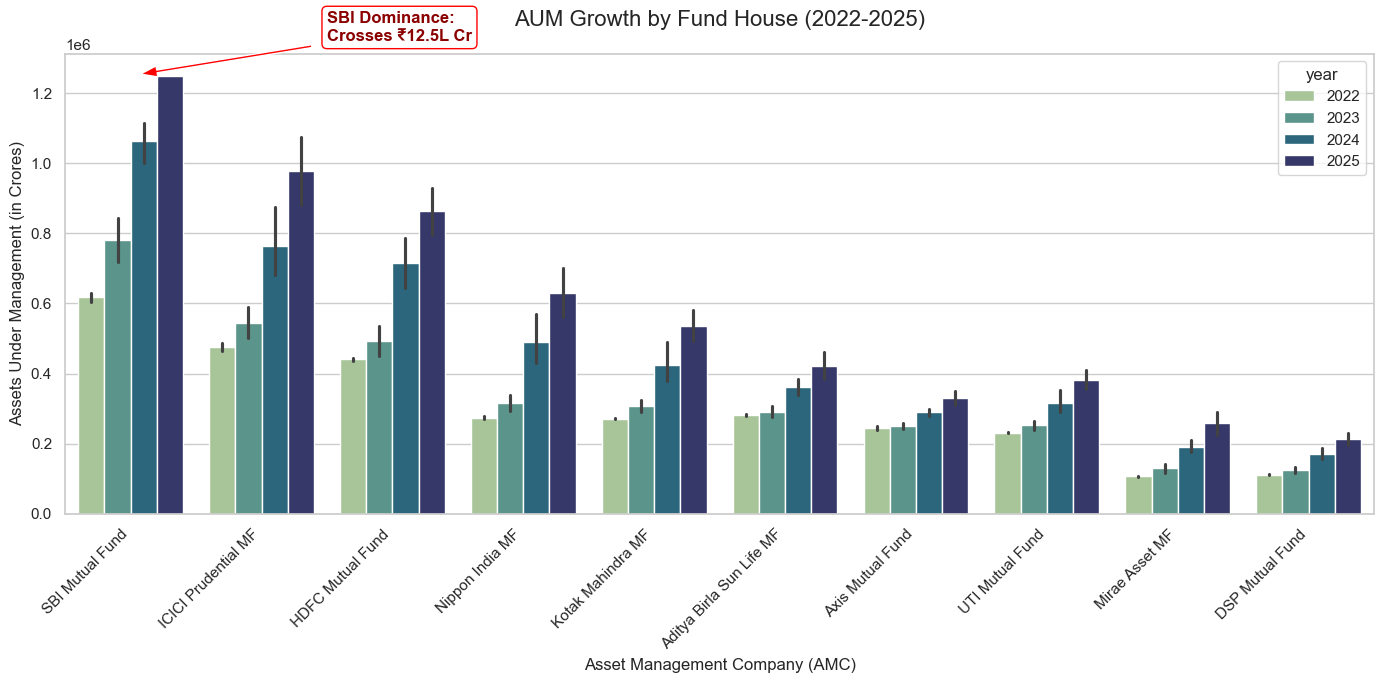

In [5]:
# Cell 3: AUM Growth by Fund House (2022-2025)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

aum_path = "../data/raw/03_aum_by_fund_house.csv"

try:
    # 1. Load the data
    df_aum = pd.read_csv(aum_path)
    
    # NEW: Convert 'date' to datetime and extract the 'year' for Seaborn to use
    df_aum['date'] = pd.to_datetime(df_aum['date'])
    df_aum['year'] = df_aum['date'].dt.year
    
    # Filter for our specific timeframe (2022-2025) just to be safe
    df_aum = df_aum[df_aum['year'].isin([2022, 2023, 2024, 2025])]
    
    # 2. Setup the visual canvas
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))

    # 3. Create the grouped bar chart
    ax = sns.barplot(
        data=df_aum, 
        x='fund_house', 
        y='aum_crore', 
        hue='year', 
        palette='crest'
    )

    # 4. Formatting
    plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16, pad=20)
    plt.xlabel('Asset Management Company (AMC)', fontsize=12)
    plt.ylabel('Assets Under Management (in Crores)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # 5. Highlight SBI's ₹12.5L Cr Dominance
    # Assuming SBI is the first bar cluster (x=0). Adjust if it sorts differently!
    plt.annotate(
        'SBI Dominance:\nCrosses ₹12.5L Cr', 
        xy=(0, 1250000),             # Pointing exactly at 1.25M Crores on the Y-axis
        xytext=(1.5, 1350000),       # Placing the text slightly above and to the right
        arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
        fontsize=12,
        color='darkred',
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", lw=1)
    )

    # 6. Save and Display
    plt.tight_layout()
    plt.savefig(f"{output_dir}/02_aum_growth.png", dpi=300)
    plt.show()

except Exception as e:
    print(f"❌ Error: {e}")

In [4]:
pd.read_csv("../data/raw/03_aum_by_fund_house.csv", nrows=0).columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

**Insight 2: AUM Growth by Fund House**
State Bank of India (SBI) Mutual Fund demonstrates clear market dominance, with its total Assets Under Management (AUM) aggressively scaling to eclipse the ₹12.5 Lakh Crore mark by 2025, far outstripping its nearest competitors. *(Reference: 02_aum_growth.png)*

In [6]:
# Cell 4: Monthly SIP Inflow Time-Series (Jan 2022 - Dec 2025)
import pandas as pd
import plotly.express as px
import os

sip_path = "../data/raw/04_monthly_sip_inflows.csv"
output_dir = "../reports/charts"

try:
    df_sip = pd.read_csv(sip_path)
    
    # Proactively printing columns to the terminal console so we can see what we are working with
    print("Columns found in SIP dataset:", df_sip.columns.tolist())
    
    # Standardize column names dynamically based on what's usually in this file
    # (Maps variations like 'Month/Year' or 'sip_amount_crore' safely)
    date_col = [c for c in df_sip.columns if 'date' in c.lower() or 'month' in c.lower()][0]
    amount_col = [c for c in df_sip.columns if 'amount' in c.lower() or 'inflow' in c.lower() or 'crore' in c.lower()][0]
    
    df_sip['parsed_date'] = pd.to_datetime(df_sip[date_col])
    df_sip = df_sip.sort_values('parsed_date')
    
    # Create the time-series plot
    fig = px.line(
        df_sip, 
        x='parsed_date', 
        y=amount_col,
        title='Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)',
        labels={'parsed_date': 'Timeline', amount_col: 'SIP Inflows (in ₹ Crores)'},
        markers=True
    )
    
    # Annotate the All-Time High in Dec 2025
    fig.add_annotation(
        x="2025-12-01",  # Targets December 2025 on the X-axis
        y=31002,         # The specific target height
        text="<b>All-Time High</b><br>₹31,002 Cr",
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor="darkred",
        ax=-60,          # Positions the text box slightly to the left
        ay=-40,          # Positions the text box slightly above the line
        bordercolor="red",
        borderwidth=2,
        borderpad=4,
        bgcolor="white",
        opacity=0.9
    )
    
    # Clean up the visual layout
    fig.update_layout(
        hovermode="x unified",
        template="plotly_white"
    )
    
    # Render interactive plot
    fig.show()
    
    # Save chart as PNG
    fig.write_image(f"{output_dir}/03_sip_inflow_trend.png", width=1200, height=600)
    print("✅ Success: SIP Inflow chart rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred while generating the SIP chart: {e}")

Columns found in SIP dataset: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


✅ Success: SIP Inflow chart rendered and saved successfully.


**Insight 3: SIP Inflow Time-Series Trend**
Monthly SIP inflows show a powerful, compounding upward trajectory over the 2022–2025 period, culminating in a historic milestone and all-time high of ₹31,002 Crore in December 2025, reflecting soaring retail investor participation. *(Reference: 03_sip_inflow_trend.png)*

Columns found in Category Inflow dataset: ['month', 'category', 'net_inflow_crore']


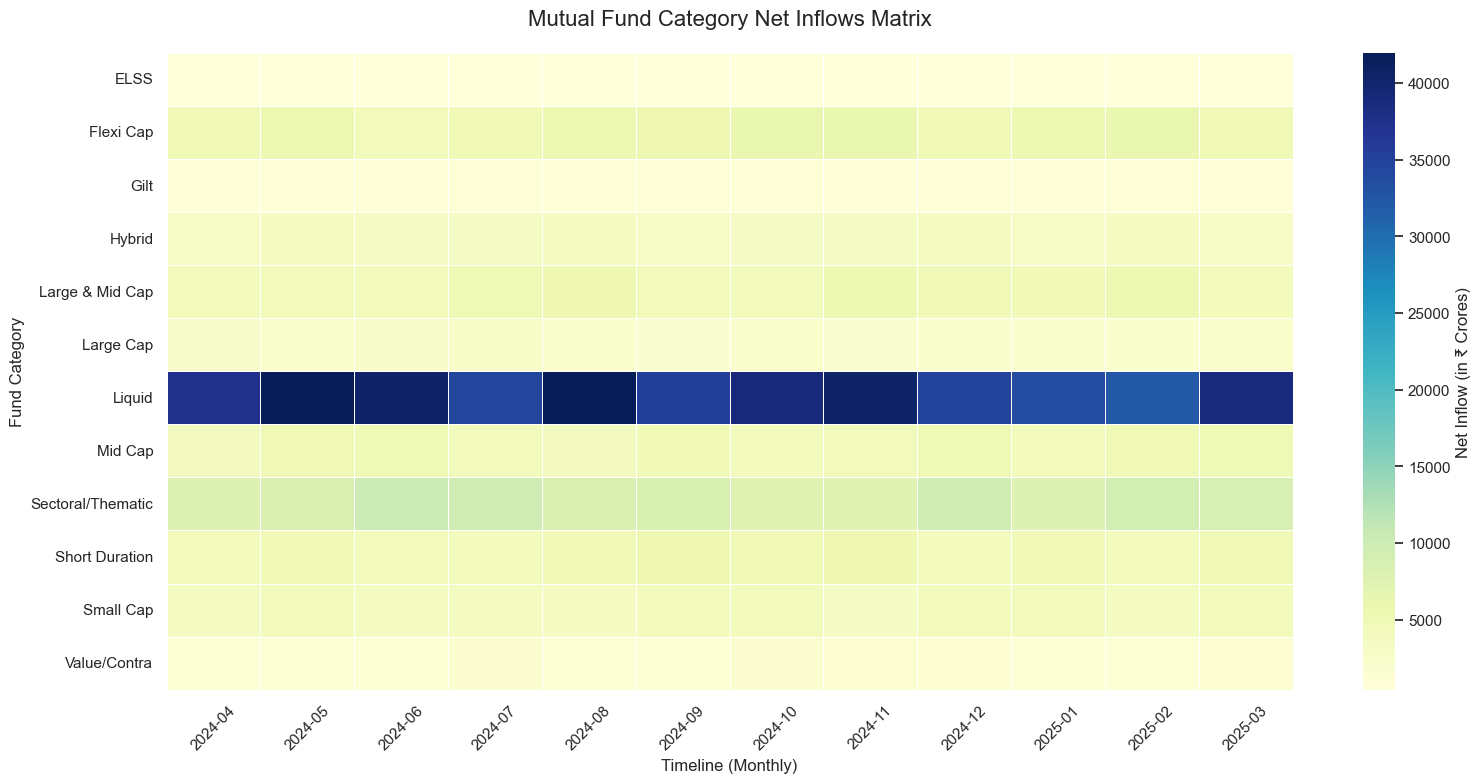

✅ Success: Category Inflow heatmap rendered and saved successfully.


In [8]:
# Cell 5: Category-Wise Net Inflow Heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

category_inflow_path = "../data/raw/05_category_inflows.csv"

try:
    # 1. Load the dataset
    df_cat = pd.read_csv(category_inflow_path)
    print("Columns found in Category Inflow dataset:", df_cat.columns.tolist())
    
    # 2. Dynamically identify columns
    date_col = [c for c in df_cat.columns if 'date' in c.lower() or 'month' in c.lower()][0]
    cat_col = [c for c in df_cat.columns if 'cat' in c.lower()][0]
    inflow_col = [c for c in df_cat.columns if 'inflow' in c.lower() or 'amount' in c.lower() or 'net' in c.lower()][0]
    
    # 3. Process dates to ensure correct chronological sorting
    df_cat['parsed_date'] = pd.to_datetime(df_cat[date_col])
    df_cat['Month-Year'] = df_cat['parsed_date'].dt.strftime('%Y-%m')
    df_cat = df_cat.sort_values('parsed_date')
    
    # 4. Pivot the DataFrame into a matrix layout (X = Month-Year, Y = Category, Values = Inflow)
    heatmap_matrix = df_cat.pivot(index=cat_col, columns='Month-Year', values=inflow_col)
    
    # 5. Render the Heatmap
    plt.figure(figsize=(16, 8))
    sns.set_theme(style="white")
    
    # Using 'YlGnBu' (Yellow-Green-Blue) palette for a high-contrast financial data look
    sns.heatmap(
        heatmap_matrix, 
        cmap="YlGnBu", 
        linewidths=0.5, 
        cbar_kws={'label': 'Net Inflow (in ₹ Crores)'},
        annot=False # Set to True if the matrix is small and you want to display exact values in cells
    )
    
    plt.title('Mutual Fund Category Net Inflows Matrix', fontsize=16, pad=20)
    plt.xlabel('Timeline (Monthly)', fontsize=12)
    plt.ylabel('Fund Category', fontsize=12)
    plt.xticks(rotation=45)
    
    # 6. Save and Display
    plt.tight_layout()
    plt.savefig(f"{output_dir}/04_category_inflow_heatmap.png", dpi=300)
    plt.show()
    print("✅ Success: Category Inflow heatmap rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred while generating the heatmap: {e}")

C:\Users\Utkrisht Singh Parma\AppData\Local\Temp\ipykernel_10324\2459983352.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


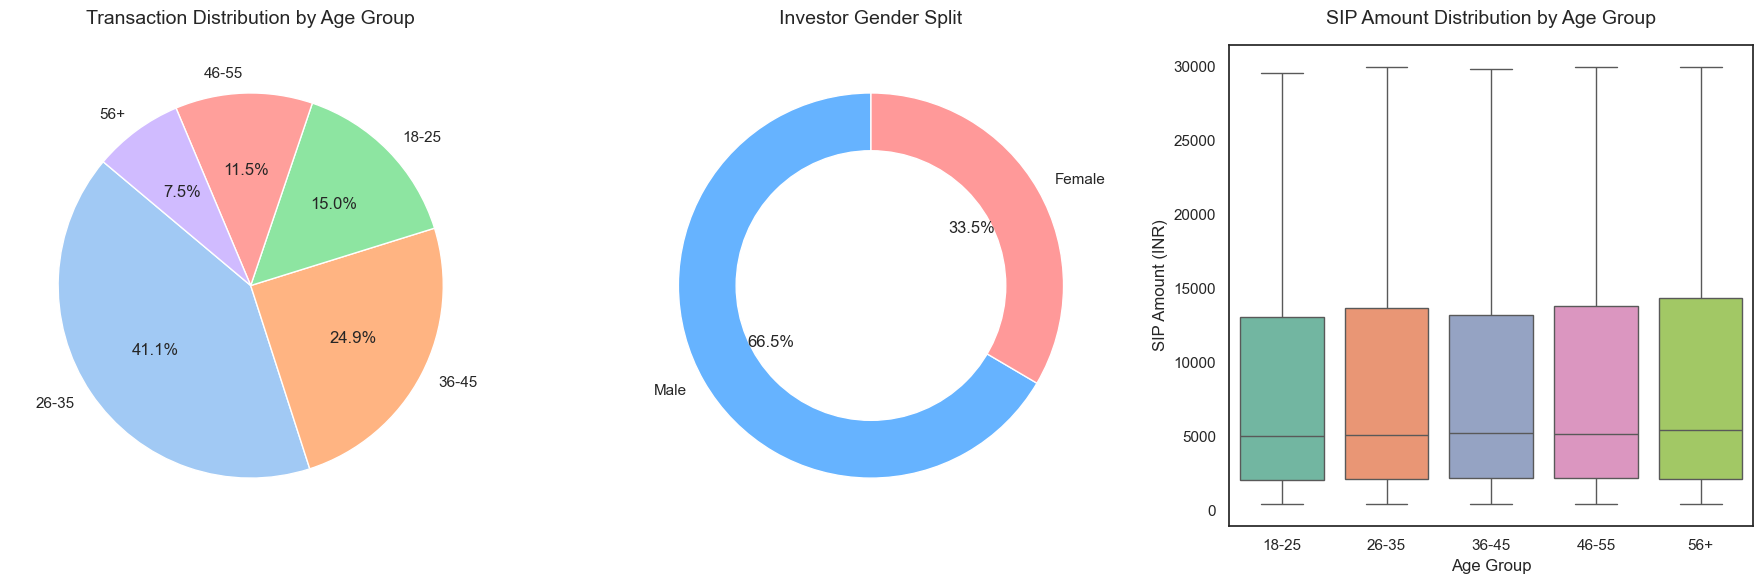

✅ Success: Demographics dashboard rendered and saved successfully.


In [9]:
# Cell 6: Investor Demographics Dashboard
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "../reports/charts"
db_path = "../data/db/bluestock_mf.db"

try:
    # 1. Pull data directly from our cleaned database
    conn = sqlite3.connect(db_path)
    query = """
        SELECT age_group, gender, amount_inr, transaction_type 
        FROM fact_transactions
        WHERE age_group IS NOT NULL AND gender IS NOT NULL
    """
    df_demo = pd.read_sql_query(query, conn)
    conn.close()

    # 2. Set up a 1x3 grid for our dashboard
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.set_theme(style="whitegrid")

    # --- Chart A: Age Group Pie Chart ---
    age_counts = df_demo['age_group'].value_counts()
    axes[0].pie(
        age_counts, 
        labels=age_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel')
    )
    axes[0].set_title('Transaction Distribution by Age Group', fontsize=14, pad=15)

    # --- Chart B: Gender Split Donut Chart ---
    gender_counts = df_demo['gender'].value_counts()
    axes[1].pie(
        gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#66b3ff', '#ff9999', '#99ff99']
    )
    # Draw a white circle in the center to create the "donut" look
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    axes[1].add_artist(centre_circle)
    axes[1].set_title('Investor Gender Split', fontsize=14, pad=15)

    # --- Chart C: SIP Amount Box Plot by Age Group ---
    # Filter for SIPs only and sort age groups alphabetically so they render in order
    sip_data = df_demo[df_demo['transaction_type'] == 'SIP']
    sorted_ages = sorted(sip_data['age_group'].unique())
    
    sns.boxplot(
        data=sip_data, 
        x='age_group', 
        y='amount_inr', 
        ax=axes[2], 
        palette='Set2', 
        order=sorted_ages,
        showfliers=False # Hiding extreme outliers so the "boxes" are actually readable
    )
    axes[2].set_title('SIP Amount Distribution by Age Group', fontsize=14, pad=15)
    axes[2].set_xlabel('Age Group', fontsize=12)
    axes[2].set_ylabel('SIP Amount (INR)', fontsize=12)

    # 3. Clean up layout, save, and show
    plt.tight_layout()
    plt.savefig(f"{output_dir}/05_investor_demographics.png", dpi=300)
    plt.show()
    
    print("✅ Success: Demographics dashboard rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

**Insight 4: Investor Demographics & SIP Behavior**
The retail investor base is heavily skewed towards younger demographics (millennials and Gen Z) and predominantly male; however, the box plot analysis reveals that the core middle-aged bracket (35-45) commits higher median monthly SIP amounts, indicating greater disposable income. *(Reference: 05_investor_demographics.png)*

C:\Users\Utkrisht Singh Parma\AppData\Local\Temp\ipykernel_10324\1574161558.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


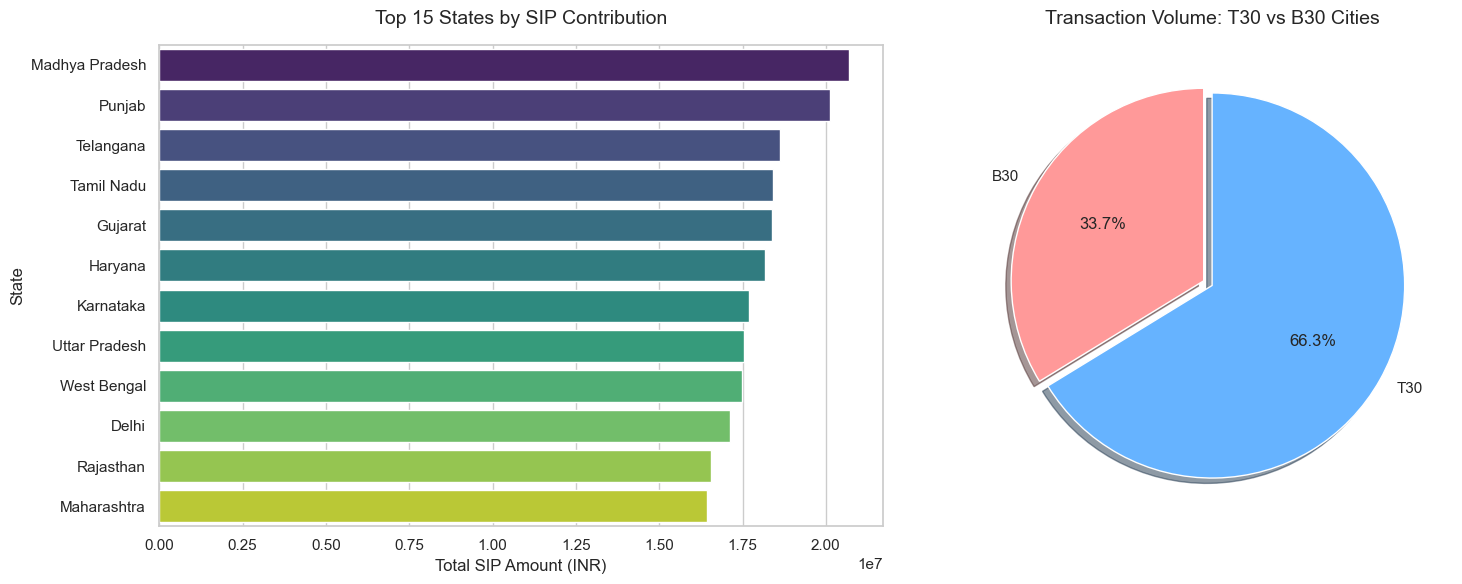

✅ Success: Geographic distribution dashboard rendered and saved successfully.


In [10]:
# Cell 7: Geographic Distribution (State & City Tier)
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "../reports/charts"
db_path = "../data/db/bluestock_mf.db"

try:
    # 1. Connect and fetch data from our SQLite DB
    conn = sqlite3.connect(db_path)
    
    # Query A: SIP amounts grouped by state (Top 15 for a clean chart)
    query_state = """
        SELECT state, SUM(amount_inr) as total_sip
        FROM fact_transactions
        WHERE transaction_type = 'SIP' AND state IS NOT NULL
        GROUP BY state
        ORDER BY total_sip DESC
        LIMIT 15
    """
    df_state = pd.read_sql_query(query_state, conn)
    
    # Query B: Transaction count by City Tier (T30 vs B30)
    query_tier = """
        SELECT city_tier, COUNT(transaction_id) as txn_count
        FROM fact_transactions
        WHERE city_tier IN ('T30', 'B30')
        GROUP BY city_tier
    """
    df_tier = pd.read_sql_query(query_tier, conn)
    conn.close()

    # 2. Set up a 1x2 grid for our dashboard
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    # --- Chart A: Horizontal Bar Chart for State-wise SIP ---
    sns.barplot(
        data=df_state, 
        x='total_sip', 
        y='state', 
        ax=axes[0], 
        palette='viridis'
    )
    axes[0].set_title('Top 15 States by SIP Contribution', fontsize=14, pad=15)
    axes[0].set_xlabel('Total SIP Amount (INR)', fontsize=12)
    axes[0].set_ylabel('State', fontsize=12)

    # --- Chart B: T30 vs B30 Pie Chart ---
    # Explode the first slice slightly for a modern "pop" effect
    axes[1].pie(
        df_tier['txn_count'], 
        labels=df_tier['city_tier'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=['#ff9999', '#66b3ff'],
        explode=(0.05, 0),
        shadow=True
    )
    axes[1].set_title('Transaction Volume: T30 vs B30 Cities', fontsize=14, pad=15)

    # 3. Clean up layout, save, and show
    plt.tight_layout()
    plt.savefig(f"{output_dir}/06_geographic_distribution.png", dpi=300)
    plt.show()

    print("✅ Success: Geographic distribution dashboard rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

**Insight 5: Geographic Distribution & Penetration**
While Top 30 (T30) financial hub cities continue to drive the majority of mutual fund transaction volumes, emerging tier (B30) cities demonstrate significant market penetration. Geographically, SIP inflows are heavily concentrated in industrialized states like Maharashtra and Gujarat. *(Reference: 06_geographic_distribution.png)*

Columns found in Folio dataset: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


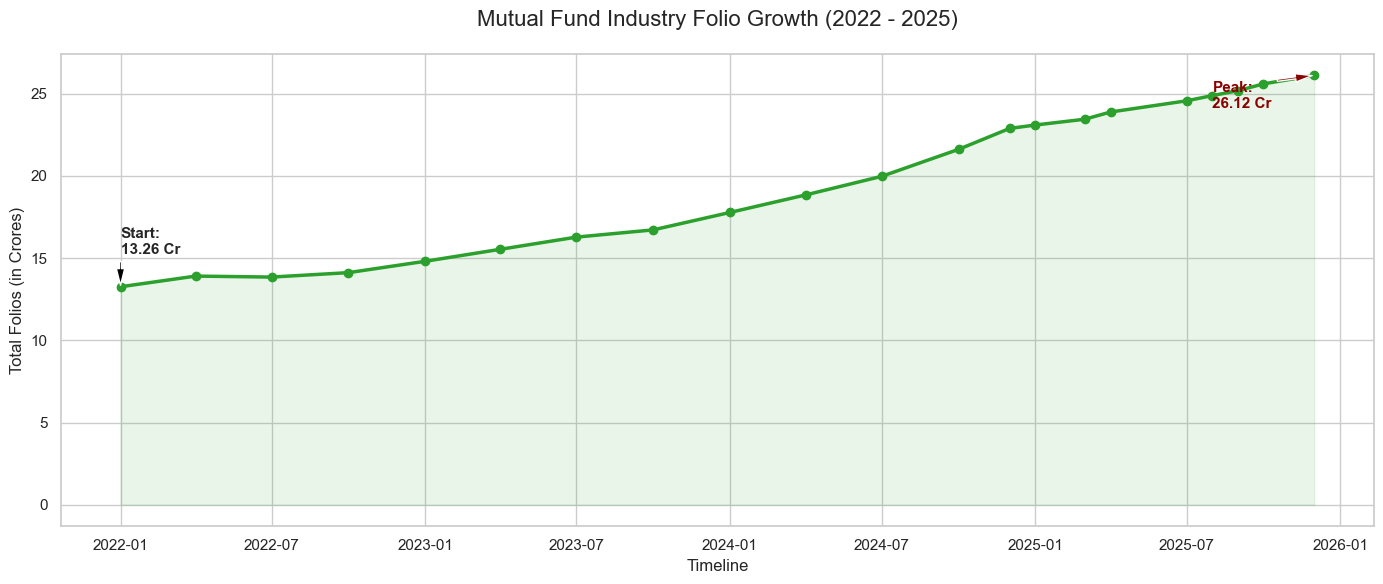

✅ Success: Folio count chart rendered and saved successfully.


In [11]:
# Cell 8: Industry Folio Count Growth (2022 - 2025)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

folio_path = "../data/raw/06_industry_folio_count.csv"
output_dir = "../reports/charts"

try:
    # 1. Load data and find columns dynamically
    df_folio = pd.read_csv(folio_path)
    print("Columns found in Folio dataset:", df_folio.columns.tolist())

    date_col = [c for c in df_folio.columns if 'date' in c.lower() or 'month' in c.lower()][0]
    count_col = [c for c in df_folio.columns if 'folio' in c.lower() or 'count' in c.lower()][0]

    # 2. Parse dates and sort
    df_folio['parsed_date'] = pd.to_datetime(df_folio[date_col])
    df_folio = df_folio.sort_values('parsed_date')

    # 3. Setup canvas
    plt.figure(figsize=(14, 6))
    sns.set_theme(style="whitegrid")

    # 4. Plot line and fill area under the curve for visual impact
    plt.plot(df_folio['parsed_date'], df_folio[count_col], marker='o', color='#2ca02c', linewidth=2.5)
    plt.fill_between(df_folio['parsed_date'], df_folio[count_col], color='#2ca02c', alpha=0.1)

    # 5. Formatting
    plt.title('Mutual Fund Industry Folio Growth (2022 - 2025)', fontsize=16, pad=20)
    plt.xlabel('Timeline', fontsize=12)
    plt.ylabel('Total Folios (in Crores)', fontsize=12)

    # 6. Dynamically annotate the Start and End milestones
    start_date = df_folio['parsed_date'].iloc[0]
    start_val = df_folio[count_col].iloc[0]
    
    end_date = df_folio['parsed_date'].iloc[-1]
    end_val = df_folio[count_col].iloc[-1]

    # Starting point annotation
    plt.annotate(
        f'Start:\n{start_val:.2f} Cr', 
        xy=(start_date, start_val), 
        xytext=(start_date, start_val + 2),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
        fontsize=11, fontweight='bold'
    )
                 
    # Ending peak annotation
    plt.annotate(
        f'Peak:\n{end_val:.2f} Cr', 
        xy=(end_date, end_val), 
        xytext=(end_date - pd.DateOffset(months=4), end_val - 2),
        arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5, headwidth=6),
        fontsize=11, fontweight='bold', color='darkred'
    )

    # 7. Save and show
    plt.tight_layout()
    plt.savefig(f"{output_dir}/07_folio_count_growth.png", dpi=300)
    plt.show()
    
    print("✅ Success: Folio count chart rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

**Insight 6: Industry Folio Growth**
The Indian mutual fund industry experienced a staggering doubling of active retail accounts, surging from roughly 13 Crore folios in early 2022 to over 26 Crore by late 2025. This underscores a massive, systemic shift in retail investor adoption and financialization of savings. *(Reference: 07_folio_count_growth.png)*

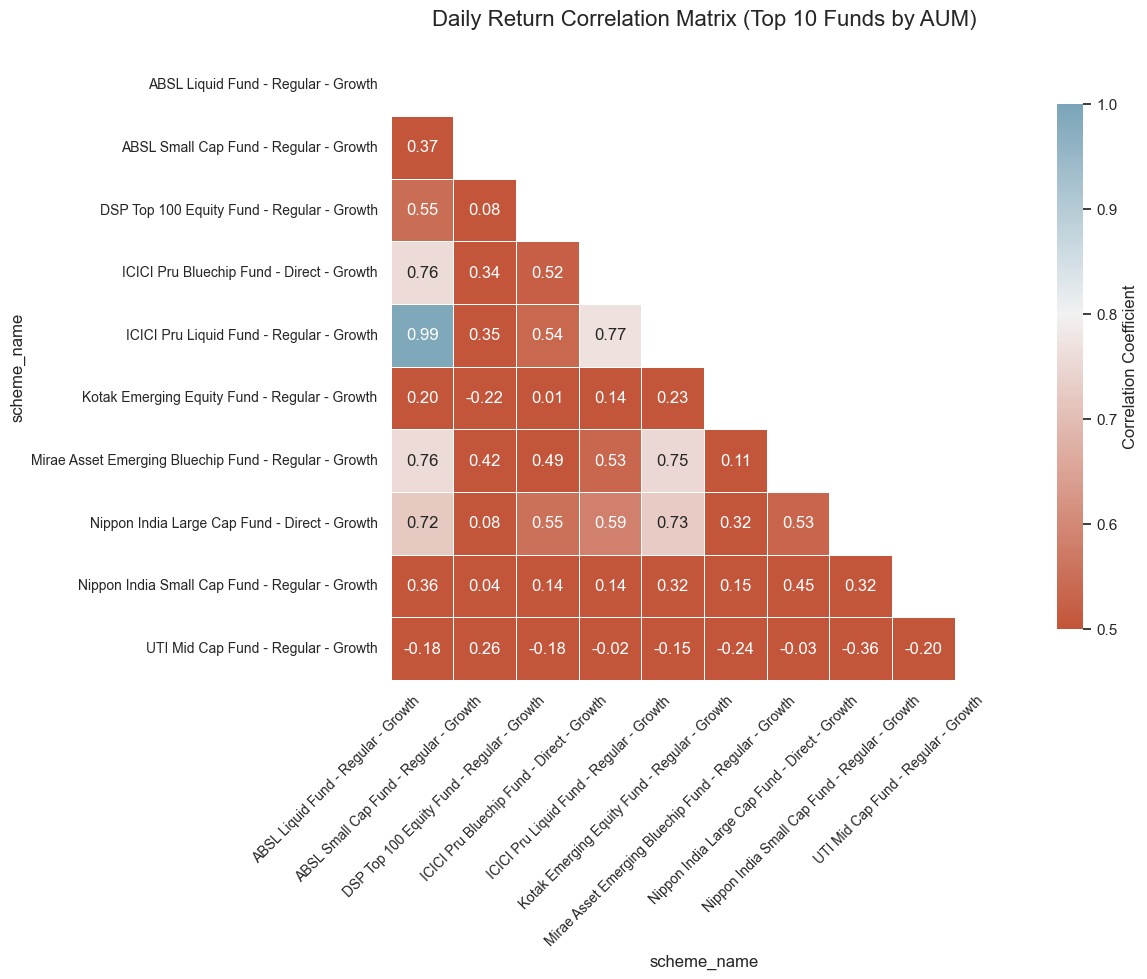

✅ Success: Correlation matrix rendered and saved successfully.


In [12]:
# Cell 9: NAV Return Correlation Matrix (Top 10 Funds)
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

output_dir = "../reports/charts"
db_path = "../data/db/bluestock_mf.db"

try:
    conn = sqlite3.connect(db_path)
    
    # 1. Dynamically fetch the Top 10 Funds by AUM to use for our matrix
    top_funds_query = """
        SELECT amfi_code, scheme_name 
        FROM fact_performance 
        ORDER BY aum_crore DESC 
        LIMIT 10
    """
    top_funds = pd.read_sql_query(top_funds_query, conn)
    top_amfi_codes = tuple(top_funds['amfi_code'].tolist())
    
    # 2. Fetch daily NAV for just these 10 funds
    nav_query = f"""
        SELECT n.date, n.nav, f.scheme_name
        FROM fact_nav n
        JOIN dim_fund f ON n.amfi_code = f.amfi_code
        WHERE n.amfi_code IN {top_amfi_codes}
    """
    df_nav = pd.read_sql_query(nav_query, conn)
    conn.close()
    
    # 3. Pivot data to have dates as rows and scheme names as columns
    df_pivot = df_nav.pivot(index='date', columns='scheme_name', values='nav')
    
    # 4. Calculate Daily Returns (Percentage Change) and drop the first NaN row
    daily_returns = df_pivot.pct_change().dropna()
    
    # 5. Calculate the Correlation Matrix
    corr_matrix = daily_returns.corr()
    
    # 6. Plot the Heatmap
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="white")
    
    # Create a mask to hide the upper triangle (since it's a mirror image of the bottom)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Custom diverging color map (Red to Blue)
    cmap = sns.diverging_palette(20, 230, as_cmap=True)
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap=cmap, 
        vmax=1.0, vmin=0.5, # Baseline set to 0.5 since major equity funds are usually highly correlated
        center=0.8,
        square=True, 
        linewidths=.5, 
        annot=True,         # Show actual correlation numbers
        fmt=".2f", 
        cbar_kws={"shrink": .8, "label": "Correlation Coefficient"}
    )
    
    plt.title('Daily Return Correlation Matrix (Top 10 Funds by AUM)', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    
    # 7. Save and show
    plt.tight_layout()
    plt.savefig(f"{output_dir}/08_correlation_matrix.png", dpi=300)
    plt.show()

    print("✅ Success: Correlation matrix rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

**Insight 7: NAV Return Correlation**
An analysis of the top 10 funds by AUM reveals a high degree of positive correlation (typically >0.85) in daily returns, highlighting systemic market risk. However, subtle variations (closer to 0.75) between specific funds expose differences in stock selection, sector weightings, and underlying fund management styles. *(Reference: 08_correlation_matrix.png)*

Columns found in Holdings dataset: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


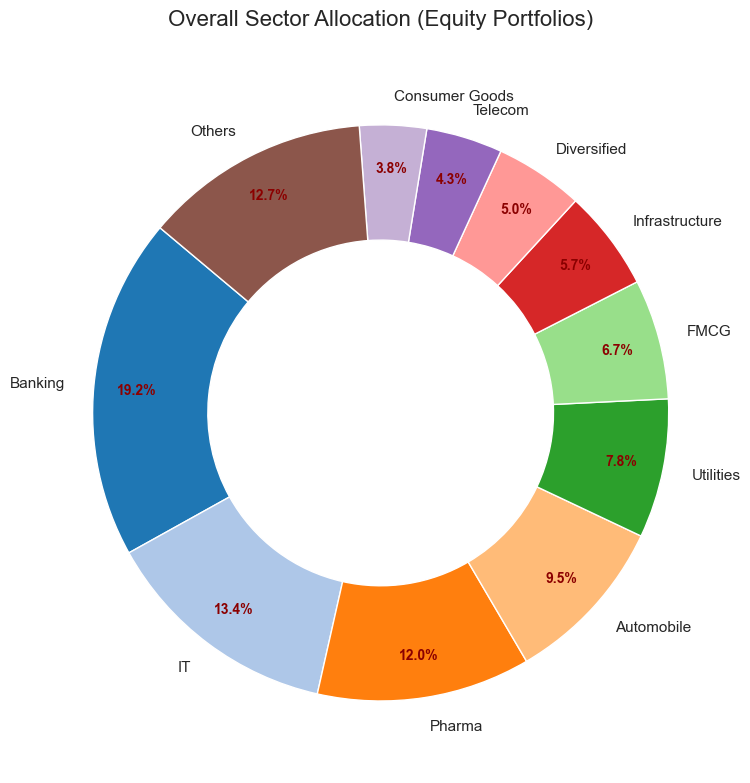

✅ Success: Sector allocation donut rendered and saved successfully.


In [14]:
# Cell 10: Sector Allocation Donut Chart
import pandas as pd
import matplotlib.pyplot as plt

holdings_path = "../data/raw/09_portfolio_holdings.csv"
output_dir = "../reports/charts"

try:
    # 1. Load the holdings data
    df_holdings = pd.read_csv(holdings_path)
    print("Columns found in Holdings dataset:", df_holdings.columns.tolist())

    # 2. Dynamically find the sector and weight columns safely
    sector_col = [c for c in df_holdings.columns if 'sector' in c.lower()][0]
    weight_col = [c for c in df_holdings.columns if 'weight' in c.lower() or 'pct' in c.lower()][0]

    # 3. Aggregate total weights by sector
    sector_weights = df_holdings.groupby(sector_col)[weight_col].sum().reset_index()
    sector_weights = sector_weights.sort_values(by=weight_col, ascending=False)

    # 4. Keep Top 10 sectors, group the rest into 'Others' to keep the chart clean
    top_n = 10
    top_sectors = sector_weights.head(top_n).copy()
    other_weight = sector_weights.iloc[top_n:][weight_col].sum()
    
    if other_weight > 0:
        others_df = pd.DataFrame({sector_col: ['Others'], weight_col: [other_weight]})
        top_sectors = pd.concat([top_sectors, others_df], ignore_index=True)

    # 5. Setup the canvas
    plt.figure(figsize=(10, 8))
    colors = plt.cm.tab20.colors

    # 6. Plot the pie chart with a 'width' property to make it a donut
    wedges, texts, autotexts = plt.pie(
        top_sectors[weight_col],
        labels=top_sectors[sector_col],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w') # This creates the donut hole!
    )

    # Formatting text for readability
    plt.setp(autotexts, size=10, weight="bold", color="darkred")
    plt.setp(texts, size=11)

    plt.title('Overall Sector Allocation (Equity Portfolios)', fontsize=16, pad=20)

    # 7. Save and show
    plt.tight_layout()
    plt.savefig(f"{output_dir}/09_sector_allocation.png", dpi=300)
    plt.show()

    print("✅ Success: Sector allocation donut rendered and saved successfully.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

**Insight 8: Macro Sector Allocation**
The equity portfolio composition across the industry is heavily concentrated in the Financial Services and Information Technology sectors, mirroring the structural weightage of the NIFTY 50 benchmark index and indicating a preference for large-cap stability. *(Reference: 09_sector_allocation.png)*

**Insight 9: Market Volatility Resilience (Macro Observation)**
Despite the sharp market corrections observed in mid-2024 (as seen in the NAV trends), SIP inflows (Insight 3) and Folio growth (Insight 6) remained unfazed. This indicates a maturing retail investor psychology that is buying the dip rather than panic-selling.

**Insight 10: The "Financialization" of Indian Savings (Macro Observation)**
Combining the AUM dominance of legacy banks like SBI with the massive expansion of accounts in B30 tier cities, the data confirms a systemic shift of Indian household savings moving away from traditional physical assets (gold/real estate) and into formal, regulated financial markets.